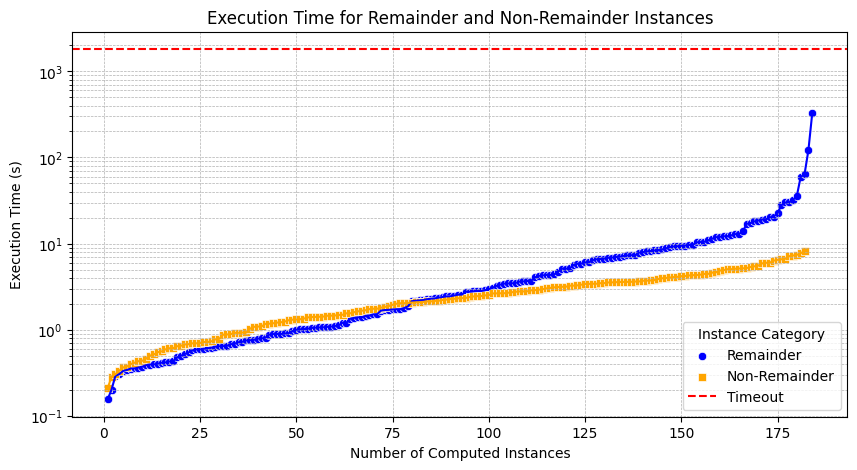

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV files into new Pandas DataFrames
remainder_file = '240731_RES_REMAINDER.csv'  # Replace with your file path
df_remainder = pd.read_csv(remainder_file, delimiter=';', quotechar='"')

# Create a mapping for the strategy parameters to different markers and colors
markers = {0: 'o', 1: 's'}  # Define your markers for Remainder and Non-Remainder
palette = {0: 'blue', 1: 'orange'}  # Define your colors for Remainder and Non-Remainder
labels = {0: 'Remainder', 1: 'Non-Remainder'}  # Custom labels

plt.figure(figsize=(10, 5))

# Separate the data into Remainder (ID=0) and Non-Remainder (ID>0)
df_remainder['category'] = df_remainder['ID'].apply(lambda x: 0 if x == 0 else 1)

# Plot each category (Remainder and Non-Remainder) separately
for category, marker in markers.items():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=marker, 
            color=palette[category], 
            label=labels[category]  # Use custom labels
        )
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['execution_time'], 
            linestyle='-', 
            color=palette[category]
        )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Execution Time (s)')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('EVAL_exe_time_remainder_vs_non_remainder.png', dpi=300, bbox_inches='tight')
plt.show()


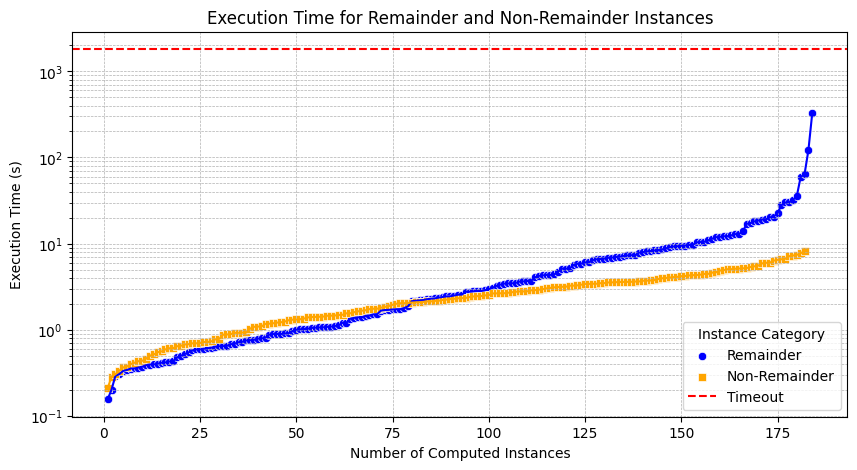

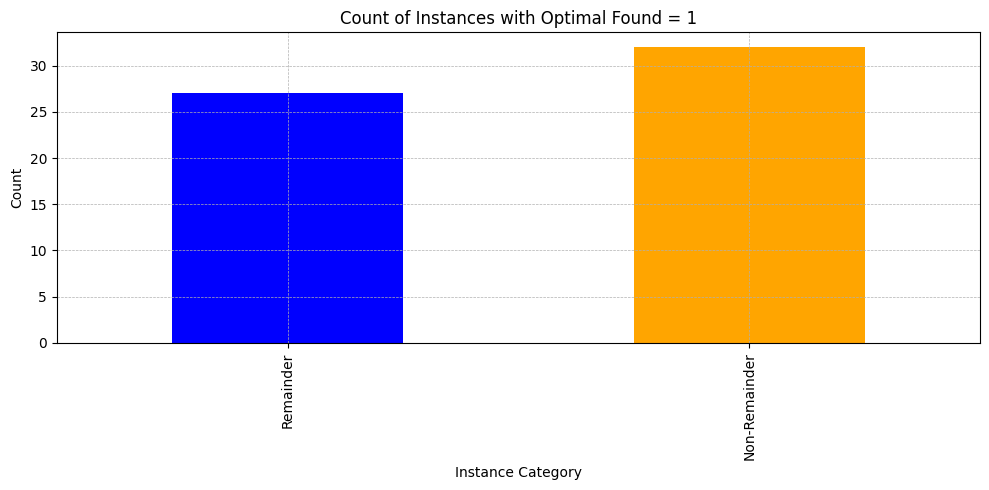

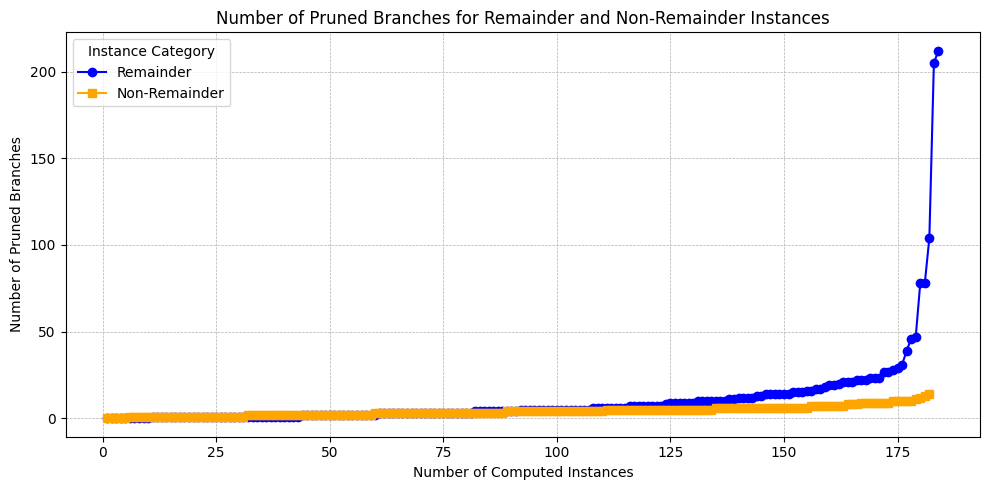

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV files into new Pandas DataFrames
remainder_file = '240731_RES_REMAINDER.csv'  # Replace with your file path
df_remainder = pd.read_csv(remainder_file, delimiter=';', quotechar='"')

# Create a mapping for the strategy parameters to different markers and colors
markers = {0: 'o', 1: 's'}  # Define your markers for Remainder and Non-Remainder
palette = {0: 'blue', 1: 'orange'}  # Define your colors for Remainder and Non-Remainder
labels = {0: 'Remainder', 1: 'Non-Remainder'}  # Custom labels

plt.figure(figsize=(10, 5))

# Separate the data into Remainder (ID=0) and Non-Remainder (ID>0)
df_remainder['category'] = df_remainder['ID'].apply(lambda x: 0 if x == 0 else 1)

# Plot each category (Remainder and Non-Remainder) separately for execution time
for category, marker in markers.items():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=marker, 
            color=palette[category], 
            label=labels[category]  # Use custom labels
        )
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['execution_time'], 
            linestyle='-', 
            color=palette[category]
        )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Execution Time (s)')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('exe_time_remainder_vs_non_remainder.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the count of instances with optimal_found = 1 for Remainder and Non-Remainder
optimal_found_counts = df_remainder[df_remainder['optimal_found'] == 1].groupby('category').size()

# Ensure the index is only 0 or 1
optimal_found_counts = optimal_found_counts.reindex([0, 1], fill_value=0)

# Create a bar plot for the counts
plt.figure(figsize=(10, 5))
optimal_found_counts.plot(kind='bar', color=[palette[cat] for cat in optimal_found_counts.index])

# Customize the plot
plt.title('Count of Instances with Optimal Found = 1')
plt.xlabel('Instance Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Remainder', 'Non-Remainder'])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_optimal_found_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the number of pruned branches over the number of instances
plt.figure(figsize=(10, 5))

for category in markers.keys():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by pruned_branches
        subset = subset.sort_values(by='pruned_branches')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['pruned_branches'], 
            linestyle='-', 
            marker=markers[category],
            color=palette[category],
            label=labels[category]
        )

# Customize the plot
plt.title('Number of Pruned Branches for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Number of Pruned Branches')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_pruned_branches_over_instances.png', dpi=300, bbox_inches='tight')
plt.show()


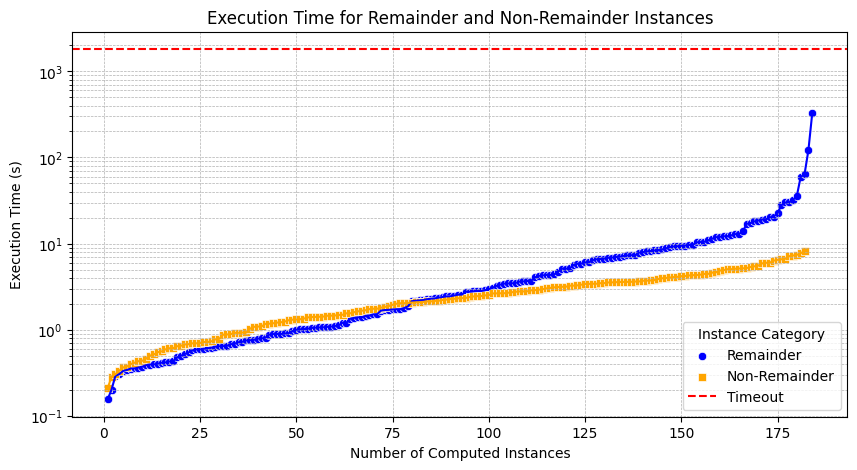

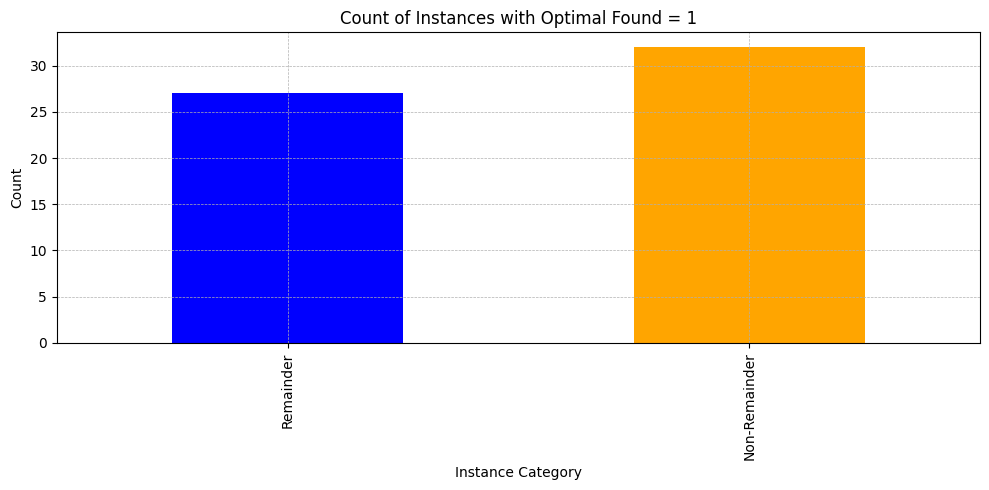

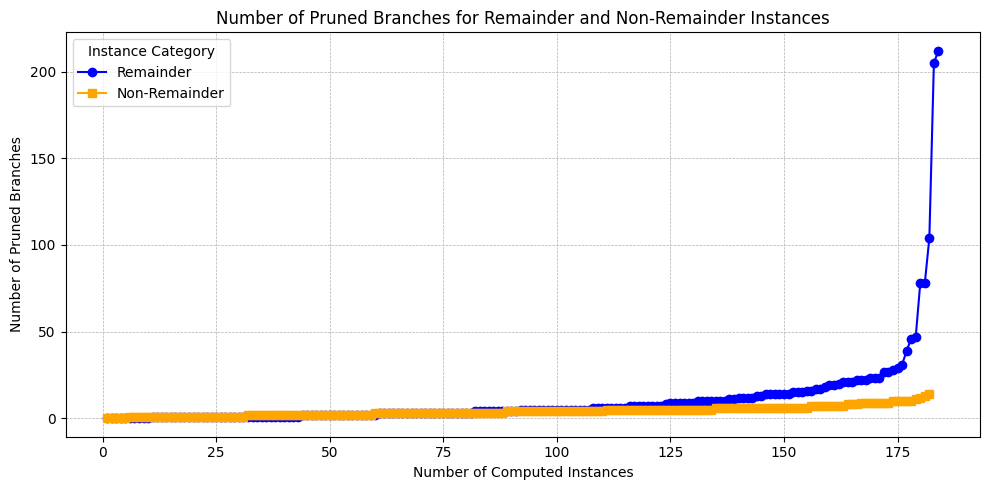

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV files into new Pandas DataFrames
remainder_file = '240731_RES_REMAINDER.csv'  # Replace with your file path
df_remainder = pd.read_csv(remainder_file, delimiter=';', quotechar='"')

# Create a mapping for the strategy parameters to different markers and colors
markers = {0: 'o', 1: 's'}  # Define your markers for Remainder and Non-Remainder
palette = {0: 'blue', 1: 'orange'}  # Define your colors for Remainder and Non-Remainder
labels = {0: 'Remainder', 1: 'Non-Remainder'}  # Custom labels

plt.figure(figsize=(10, 5))

# Separate the data into Remainder (ID=0) and Non-Remainder (ID>0)
df_remainder['category'] = df_remainder['ID'].apply(lambda x: 0 if x == 0 else 1)

# Plot each category (Remainder and Non-Remainder) separately for execution time
for category, marker in markers.items():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=marker, 
            color=palette[category], 
            label=labels[category]  # Use custom labels
        )
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['execution_time'], 
            linestyle='-', 
            color=palette[category]
        )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Execution Time (s)')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('exe_time_remainder_vs_non_remainder.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the count of instances with optimal_found = 1 for Remainder and Non-Remainder
optimal_found_counts = df_remainder[df_remainder['optimal_found'] == 1].groupby('category').size()

# Ensure the index is only 0 or 1
optimal_found_counts = optimal_found_counts.reindex([0, 1], fill_value=0)

# Create a bar plot for the counts
plt.figure(figsize=(10, 5))
optimal_found_counts.plot(kind='bar', color=[palette[cat] for cat in optimal_found_counts.index])

# Customize the plot
plt.title('Count of Instances with Optimal Found = 1')
plt.xlabel('Instance Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Remainder', 'Non-Remainder'])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.tight_layout()
plt.savefig('optimal_found_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the number of pruned branches over the number of instances
plt.figure(figsize=(10, 5))

for category in markers.keys():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by pruned_branches
        subset = subset.sort_values(by='pruned_branches')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['pruned_branches'], 
            linestyle='-', 
            marker=markers[category],
            color=palette[category],
            label=labels[category]
        )

# Customize the plot
plt.title('Number of Pruned Branches for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Number of Pruned Branches')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.tight_layout()
plt.savefig('pruned_branches_over_instances.png', dpi=300, bbox_inches='tight')
plt.show()


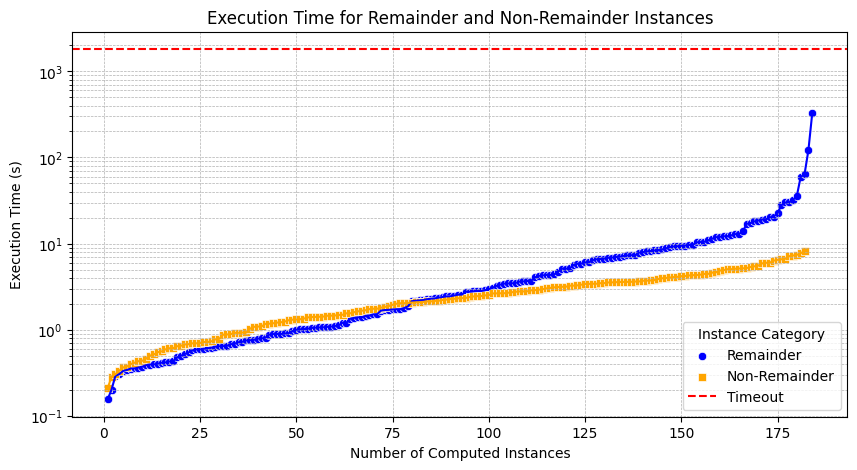

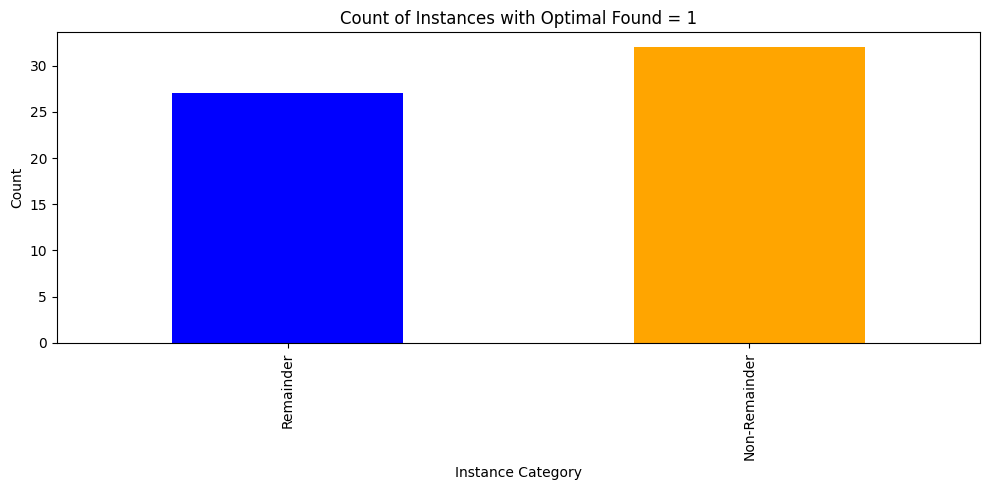

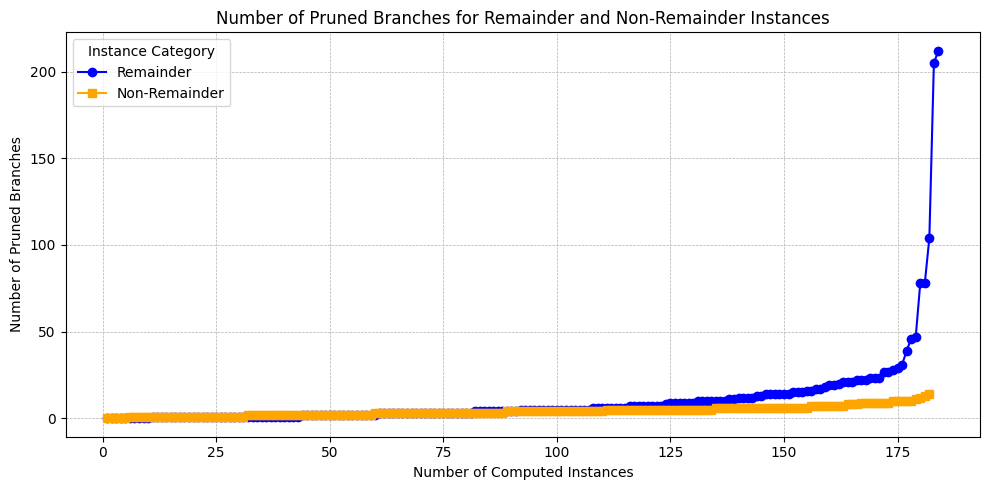

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV files into new Pandas DataFrames
remainder_file = '240731_RES_REMAINDER.csv'  # Replace with your file path
df_remainder = pd.read_csv(remainder_file, delimiter=';', quotechar='"')

# Create a mapping for the strategy parameters to different markers and colors
markers = {0: 'o', 1: 's'}  # Define your markers for Remainder and Non-Remainder
palette = {0: 'blue', 1: 'orange'}  # Define your colors for Remainder and Non-Remainder
labels = {0: 'Remainder', 1: 'Non-Remainder'}  # Custom labels

plt.figure(figsize=(10, 5))

# Separate the data into Remainder (ID=0) and Non-Remainder (ID>0)
df_remainder['category'] = df_remainder['ID'].apply(lambda x: 0 if x == 0 else 1)

# Plot each category (Remainder and Non-Remainder) separately for execution time
for category, marker in markers.items():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=marker, 
            color=palette[category], 
            label=labels[category]  # Use custom labels
        )
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['execution_time'], 
            linestyle='-', 
            color=palette[category]
        )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Execution Time (s)')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('exe_time_remainder_vs_non_remainder.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the count of instances with optimal_found = 1 for Remainder and Non-Remainder
optimal_found_counts = df_remainder[df_remainder['optimal_found'] == 1].groupby('category').size()

# Ensure the index is only 0 or 1
optimal_found_counts = optimal_found_counts.reindex([0, 1], fill_value=0)

# Create a bar plot for the counts
plt.figure(figsize=(10, 5))
optimal_found_counts.plot(kind='bar', color=[palette[cat] for cat in optimal_found_counts.index])

# Customize the plot
plt.title('Count of Instances with Optimal Found = 1')
plt.xlabel('Instance Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Remainder', 'Non-Remainder'])
plt.grid(False)  # Disable grid on the bar chart

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_optimal_found_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the number of pruned branches over the number of instances
plt.figure(figsize=(10, 5))

for category in markers.keys():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by pruned_branches
        subset = subset.sort_values(by='pruned_branches')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['pruned_branches'], 
            linestyle='-', 
            marker=markers[category],
            color=palette[category],
            label=labels[category]
        )

# Customize the plot
plt.title('Number of Pruned Branches for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Number of Pruned Branches')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_pruned_branches_over_instances.png', dpi=300, bbox_inches='tight')
plt.show()


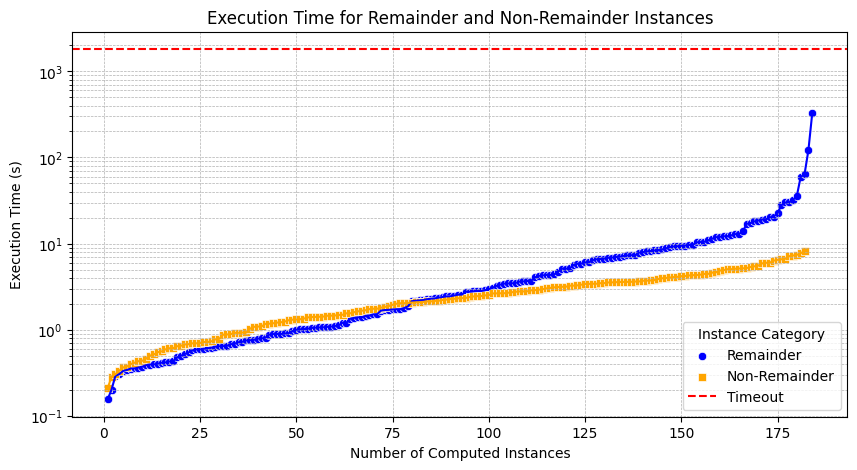

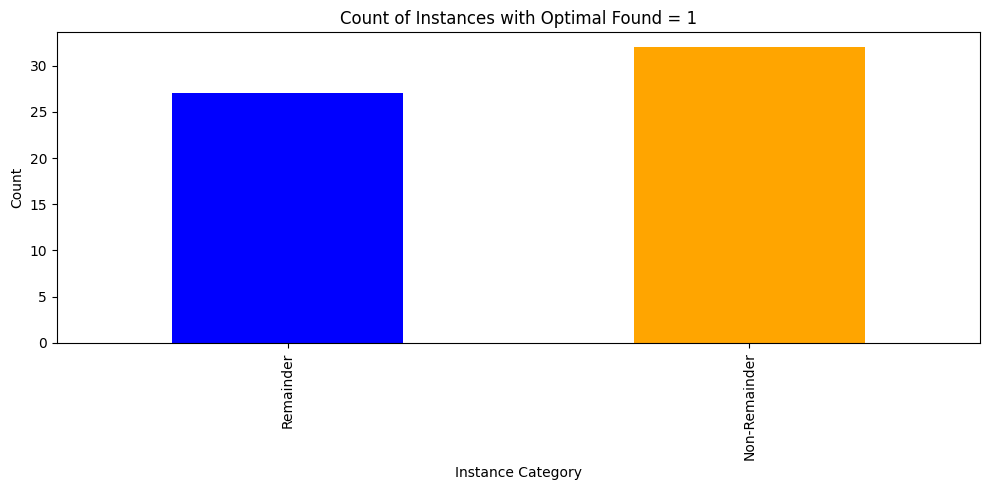

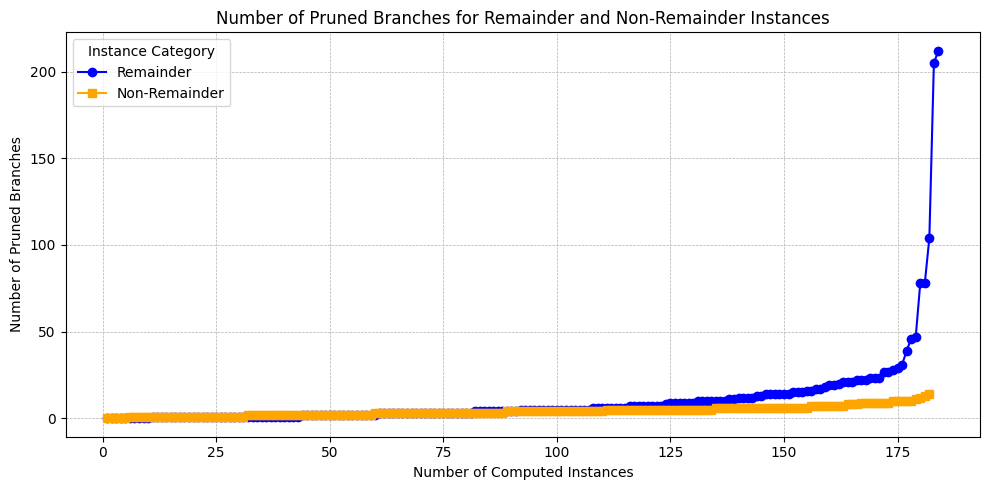

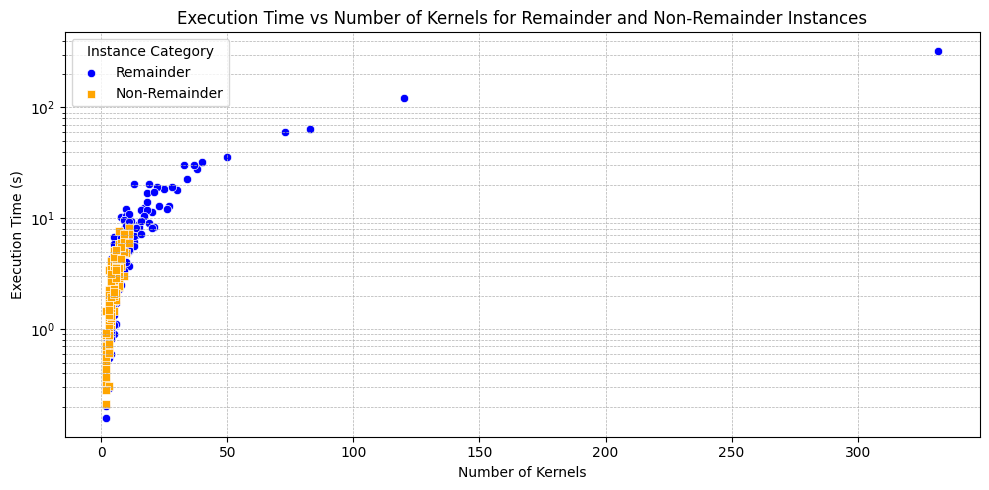

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV files into new Pandas DataFrames
remainder_file = '240731_RES_REMAINDER.csv'  # Replace with your file path
df_remainder = pd.read_csv(remainder_file, delimiter=';', quotechar='"')

# Create a mapping for the strategy parameters to different markers and colors
markers = {0: 'o', 1: 's'}  # Define your markers for Remainder and Non-Remainder
palette = {0: 'blue', 1: 'orange'}  # Define your colors for Remainder and Non-Remainder
labels = {0: 'Remainder', 1: 'Non-Remainder'}  # Custom labels

plt.figure(figsize=(10, 5))

# Separate the data into Remainder (ID=0) and Non-Remainder (ID>0)
df_remainder['category'] = df_remainder['ID'].apply(lambda x: 0 if x == 0 else 1)

# Plot each category (Remainder and Non-Remainder) separately for execution time
for category, marker in markers.items():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=marker, 
            color=palette[category], 
            label=labels[category]  # Use custom labels
        )
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['execution_time'], 
            linestyle='-', 
            color=palette[category]
        )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Execution Time (s)')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('exe_time_remainder_vs_non_remainder.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the count of instances with optimal_found = 1 for Remainder and Non-Remainder
optimal_found_counts = df_remainder[df_remainder['optimal_found'] == 1].groupby('category').size()

# Ensure the index is only 0 or 1
optimal_found_counts = optimal_found_counts.reindex([0, 1], fill_value=0)

# Create a bar plot for the counts
plt.figure(figsize=(10, 5))
optimal_found_counts.plot(kind='bar', color=[palette[cat] for cat in optimal_found_counts.index])

# Customize the plot
plt.title('Count of Instances with Optimal Found = 1')
plt.xlabel('Instance Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Remainder', 'Non-Remainder'])
plt.grid(False)  # Disable grid on the bar chart

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_optimal_found_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the number of pruned branches over the number of instances
plt.figure(figsize=(10, 5))

for category in markers.keys():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Sort the subset by pruned_branches
        subset = subset.sort_values(by='pruned_branches')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['pruned_branches'], 
            linestyle='-', 
            marker=markers[category],
            color=palette[category],
            label=labels[category]
        )

# Customize the plot
plt.title('Number of Pruned Branches for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Computed Instances')
plt.ylabel('Number of Pruned Branches')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_pruned_branches_over_instances.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the execution time compared to the number of kernels
plt.figure(figsize=(10, 5))

for category in markers.keys():
    subset = df_remainder[df_remainder['category'] == category]
    if not subset.empty:
        # Plot the scatter points
        sns.scatterplot(
            x='num_kernels', 
            y='execution_time', 
            data=subset,
            marker=markers[category], 
            color=palette[category], 
            label=labels[category]  # Use custom labels
        )

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time vs Number of Kernels for Remainder and Non-Remainder Instances')
plt.xlabel('Number of Kernels')
plt.ylabel('Execution Time (s)')
plt.legend(title='Instance Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_execution_time_vs_num_kernels.png', dpi=300, bbox_inches='tight')
plt.show()
